# Histogram diagnostic - Single histogram/PDF plot

The aim of this diagnostic is to visualise the probability density function (PDF) or histogram of a certain variable over a specified region.

In this notebook we demonstrate how to:
1. Compute a histogram using the `Histogram` class
2. Plot it using the `PlotHistogram` class
3. Optionally include reference data for comparison

In [1]:
%reload_ext autoreload
%autoreload 2

## Import the classes

In [2]:
from aqua.diagnostics import Histogram, PlotHistogram

## Setup data dictionaries

We define:
- `dataset_dict`: Configuration for the model data
- `obs_dict`: Configuration for reference/observational data (optional)
- `common_dict`: Common parameters for both datasets

In [3]:
dataset_dict = {"catalog": "climatedt-gen2", "model": "IFS-FESOM-5km", "exp": "baseline-hist", "source": "lra-r100-monthly"}

obs_dict = {"catalog": "obs", "model": "ERA5", "exp": "era5", "source": "monthly"}

common_dict = {
    "startdate": "1990-01-01",
    "enddate": "1999-12-31",
    "bins": 100,  # Number of bins for histogram
    "weighted": True,  # Use latitudinal weights
    "loglevel": "INFO",
}

## Compute histograms

We create `Histogram` objects for both model and reference data.
The `run()` method:
1. Retrieves the data from the catalog
2. Computes the histogram with `density=True` to get a PDF
3. Saves the result to a netCDF file

We'll analyze `tprate` (Total Precipitation Rate) in mm/day.

In [4]:
# Create Histogram objects
hist_dataset = Histogram(**dataset_dict, **common_dict)
hist_obs = Histogram(**obs_dict, **common_dict)

# Configuration for the variable
run_dict = {
    "var": "tprate",
    "units": "mm/day",
    "density": True,  # Get PDF instead of counts
}

# Compute histograms
hist_dataset.run(**run_dict)
hist_obs.run(**run_dict)

2026-05-11 14:19:37 :: Histogram :: INFO     -> No region provided, using lon_limits: None, lat_limits: None
2026-05-11 14:19:37 :: Histogram :: INFO     -> No region provided, using lon_limits: None, lat_limits: None
2026-05-11 14:19:37 :: Histogram :: INFO     -> Running Histogram diagnostic for tprate
2026-05-11 14:19:37 :: Histogram :: INFO     -> Retrieving data for variable tprate
2026-05-11 14:19:37 :: ConfigPath :: INFO     -> IFS-FESOM-5km_baseline-hist_lra-r100-monthly triplet found in in climatedt-gen2!
2026-05-11 14:19:38 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-05-11 14:19:38 :: FixerConfigure :: INFO     -> No fixer_name found, only convention will be applied
2026-05-11 14:19:38 :: Reader :: INFO     -> Grid metadata is lon-lat
2026-05-11 14:19:38 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-05-11 14:19:38 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
2026-05-11 14:20:

## Plot the histogram/PDF

Now we use `PlotHistogram` to visualize the computed histograms.
We can plot:
- Single model data with reference data
- Multiple models together
- With or without reference data

2026-05-11 14:20:44 :: PlotHistogram :: INFO     -> Running PlotHistogram
2026-05-11 14:20:44 :: PlotHistogram :: INFO     -> Description: Probability density function (PDF) of Total precipitation rate [mm/day] for IFS-FESOM-5km/baseline-hist vs ERA5 from 1990-01 to 1999-12.
2026-05-11 14:20:44 :: create_folder :: INFO     -> Folder ./png already exists
2026-05-11 14:20:45 :: OutputSaver :: INFO     -> Saved PNG: ./png/histogram.pdf.climatedt-gen2.IFS-FESOM-5km.baseline-hist.r1.tprate.png


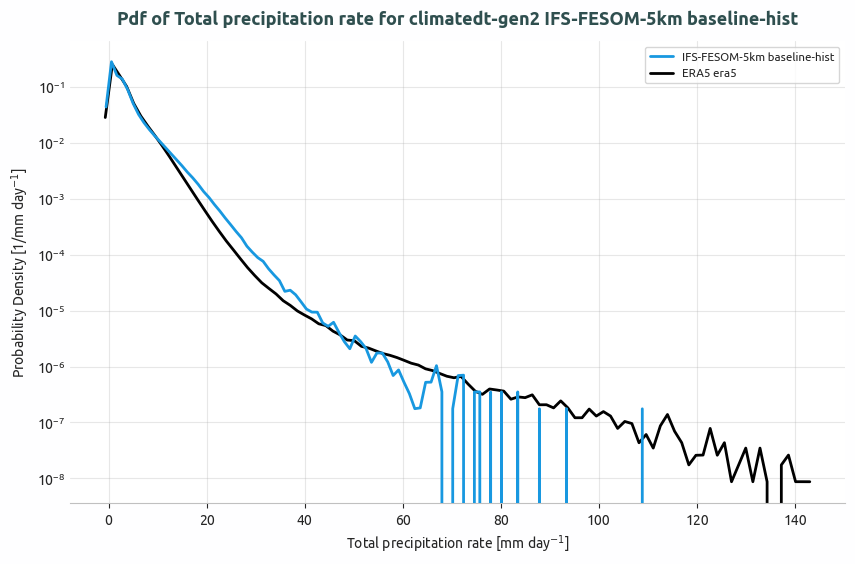

2026-05-11 14:20:45 :: PlotHistogram :: INFO     -> PlotHistogram completed successfully


In [5]:
# Setup plot with model data and reference
plot = PlotHistogram(
    data=[hist_dataset.histogram_data],  # Note: needs to be a list
    ref_data=hist_obs.histogram_data,  # Reference data
    loglevel="INFO",
)

# Generate and save the plot
plot.run(
    ylogscale=True,  # Logarithmic scale for y-axis (frequency)
    xlogscale=False,  # Linear scale for x-axis (precipitation)
    smooth=False,  # No smoothing applied
    show=True,  # Show the plot,
    format="png",
)